In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Encoder | Decoder</h1>
<h3 style="margin: 0;  color: #1e1a66">shallow networks</h3>
</div>

Imports:

In [2]:
import numpy as np
import torch
from torch import nn

import matplotlib.pyplot as plt

from Utilities.Exchanger_Device import compute_U_P_solution_exchanger_device

from Utilities.Mesh_processing import (
    refine
)

from Utilities.Plot_functions import (
    Plot_Initial_Refined_meshes,
    plot_viscosity,
    Plot_Velocity_and_Pressure,
)

---

We begin with loading and storing data in the raw data matrix $\mathbf{X} \in \mathbb{R}^{N_v \times (3+4k)}$, the $i^{th}$ row is defined as follows:

$$
\tilde{x}_i = 
\begin{bmatrix} 
x_i \\ y_i \\ \mu_1 \\ \vdots \\ \mu_k \\ p^{x}_{i,1} \\ \vdots \\ p^{x}_{i,k} \\ p^{y}_{i,1} \\ \vdots \\ p^{y}_{i,k} \\ \hat{w}_{i,1} \\ \vdots \\ \hat{w}_{i,k} \\ b_i
\end{bmatrix} \in \mathbb{R}^{3+4k}
\qquad
\mathbf{X} = 
\begin{bmatrix} 
(\tilde{x}_1)^T \\ (\tilde{x}_2)^T \\ \vdots \\ (\tilde{x}_{N_v})^T 
\end{bmatrix} 
=
\begin{bmatrix}
x_1 & y_1 & \mu_1 & \cdots & \mu_k & p^{x}_{1,1} & \cdots & p^{x}_{1,k} & p^{y}_{1,1} & \cdots & p^{y}_{1,k} & \hat{w}_{1,1} & \cdots & \hat{w}_{1,k} & b_1 \\
x_2 & y_2 & \mu_1 & \cdots & \mu_k & p^{x}_{2,1} & \cdots & p^{x}_{2,k} & p^{y}_{2,1} & \cdots & p^{y}_{2,k} & \hat{w}_{2,1} & \cdots & \hat{w}_{2,k} & b_2 \\
\vdots & \vdots & \vdots & & \vdots & \vdots &  & \vdots & \vdots & & \vdots & \vdots & & \vdots & \vdots \\
x_{N_v} & y_{N_v} & \mu_1 & \cdots & \mu_k & p^{x}_{{N_v},1} & \cdots & p^{x}_{{N_v},k} & p^{y}_{{N_v},1} & \cdots & p^{y}_{{N_v},k} & \hat{w}_{{N_v},1} & \cdots & \hat{w}_{{N_v},k} & b_{N_v}
\end{bmatrix} \in \mathbb{R}^{N_v \times (3+4k)}
$$

where:

* $(x_i, y_i)$ are the spatial coordinates of node $i$, denoted as $x_i \in \Omega$.


* $\boldsymbol{\mu} = [\mu_1, \dots, \mu_p]^\top$ are the prescribed global viscosity parameters at the $p$ control points.


* $(p^x_m, p^y_m)$ are the spatial coordinates of the $m$-th control point $x_m$ for $m \in \{1, \dots, p\}$.


* $\psi_m(x_i) = \frac{w_m(x_i)}{\sum_{j=1}^p w_j(x_i)}$ is the normalized Shepard basis function for control point $m$ evaluated at node $x_i$.


* $w_m(x_i) = \frac{1}{\max(d_m, \epsilon)^\gamma}$ is the inverse-distance weight, where $d_m = \vert{}x_i - x_m\vert{}_2$ is the Euclidean distance from node $x_i$ to control point $x_m$, $\epsilon$ is the softening parameter, and $\gamma$ is the decay power.


* $b_i$ is the boundary condition flag for node $i$ extracted from the mesh geometry.

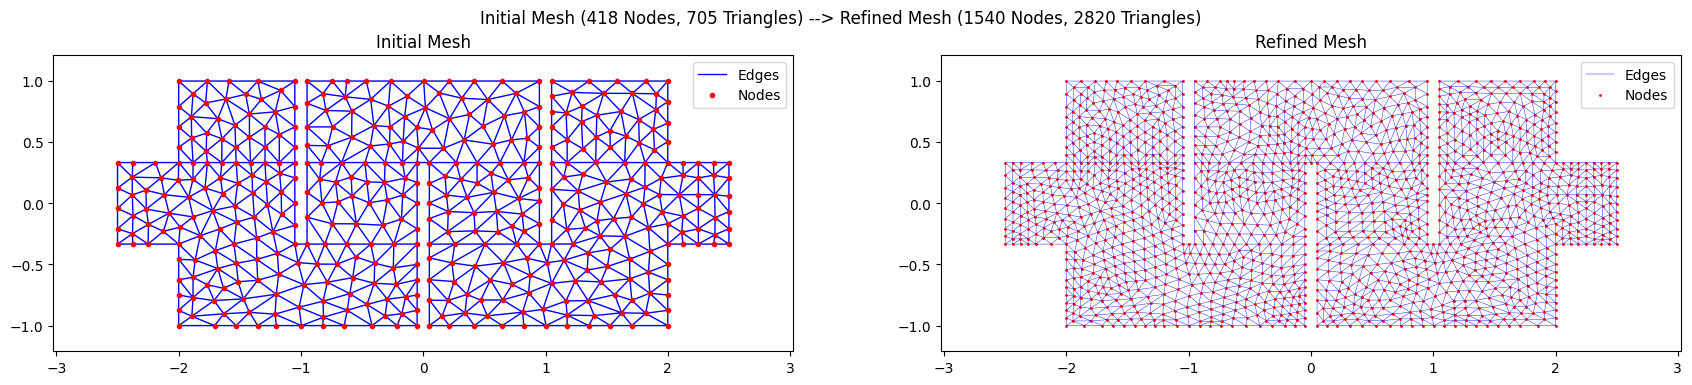

In [3]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(
    data_path='Meshes/exchanger_device_altered_mesh_data.npz',
    num_of_refinements=1,
    figsize=(21, 4),
    plot=True, name=''
)
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [4]:
def viscosity_field(p, param_vec, loc, power: float = 2.0, eps: float = 1e-12):
        """
        Inverse-distance weighted viscosity at every node in p (N, 2).
        power=2  is the standard Shepard interpolation.
        Increase power (e.g. 4-6) for sharper, more localised influence zones.
        """
        diff = p[:, None, :] - loc[None, :, :]
        d    = np.linalg.norm(diff, ord=2, axis=2)   

        exact = d < eps
        hit   = exact.any(axis=1)

        w  = 1.0 / np.where(d < eps, eps, d) ** power
        w /= w.sum(axis=1, keepdims=True)
        nu = (w * param_vec[None, :]).sum(axis=1) 

        if hit.any():
            knot_idx = np.argmax(exact[hit], axis=1)
            nu[hit]  = param_vec[knot_idx]

        return nu, w

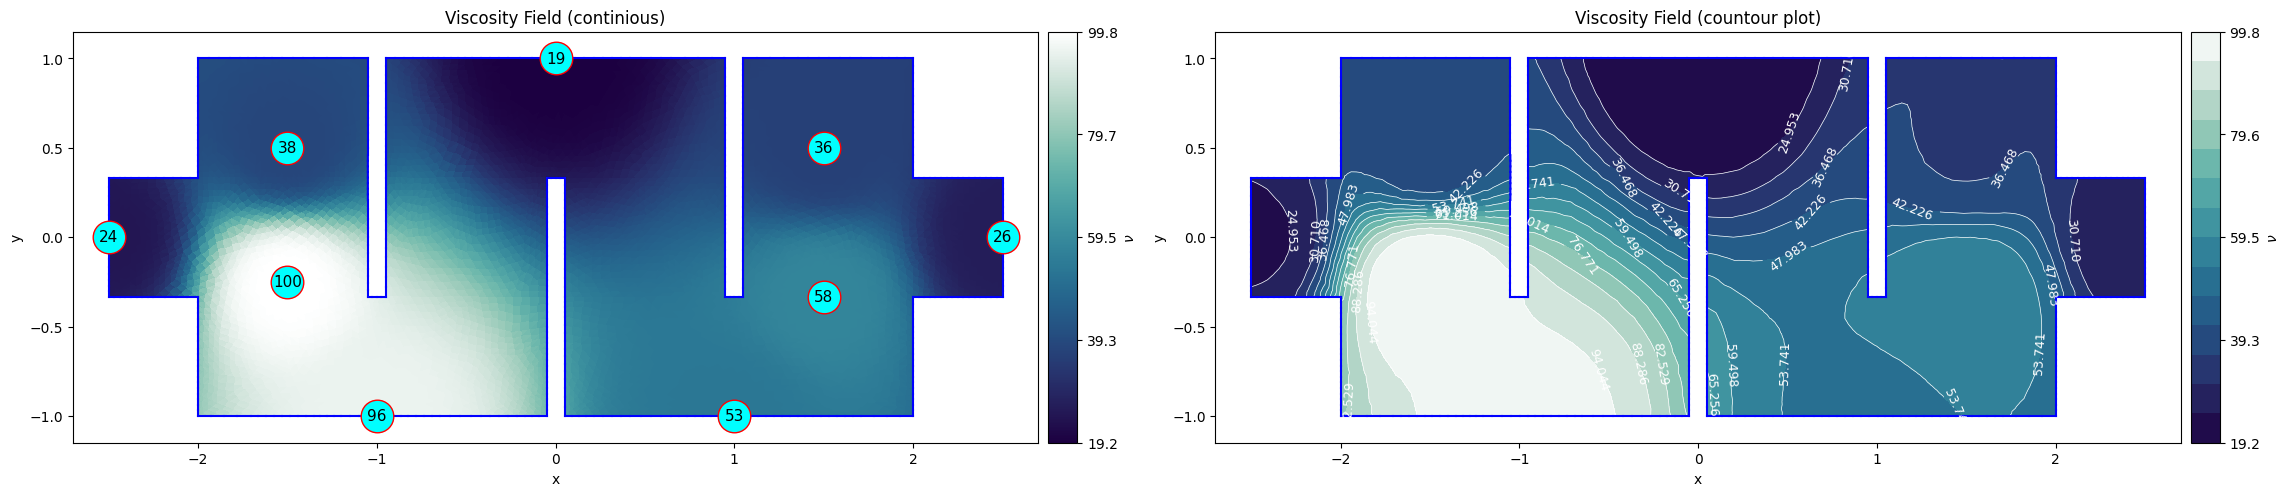

In [ ]:
alpha = 1
parameter_loc = np.array([
      [-2.5,  0.0],
      [-1.5,  alpha/2],
      [-1.5,  -alpha/4],
      [-1.0, -alpha],
      [ 0.0,  alpha],
      [ 1.0, -alpha],
      [ 1.5, -alpha/3],
      [ 1.5,  alpha/2],
      [ 2.5,  0.0],
      ])

mu = np.array([100, 0.1, 30, 50, 20, 50, 30, 0.1, 100])

centroids = p_fine[t_fine[:, :3]].mean(axis=1)
nu_field_elem, _ = viscosity_field(centroids, mu, parameter_loc, power=4.0)
_, w_nodes   = viscosity_field(p_fine, mu, parameter_loc, power=4.0)

nu_dict = {
        "pts":  parameter_loc,
        "vals": mu
    }

plot_viscosity(p_fine, t_fine, e_fine, nu_field_elem, nu_dict, 
               n_levels=15, figsize=(23, 10), 
               name=f'{mu}', savetype="png")

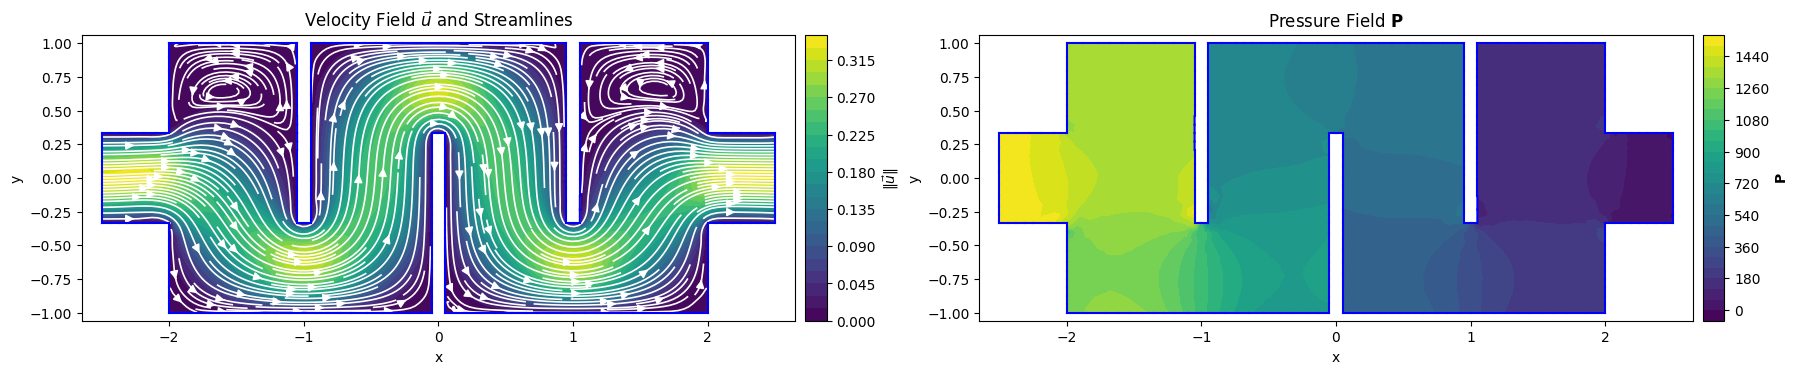

In [6]:
ux, uy, p_sol = compute_U_P_solution_exchanger_device(p_fine, t_fine, e_fine, p_coarse, t_coarse, kinematic_viscosity=nu_field_elem)
Plot_Velocity_and_Pressure(p_fine, t_fine, p_coarse, t_coarse, e_coarse, ux, uy, p_sol, name='')

### Data matrix $\mathbf X \in \mathbb{R}^{N_v \times (3+4k)}$ function:

In [7]:
def X_data_matrix(p:np.ndarray, flag:np.ndarray, mu_param:np.ndarray, mu_loc:np.ndarray, bases_at_x:np.ndarray) -> torch.Tensor:
    """
    Constructs the feature matrix **X** in a single pass.
    
    Parameters:
        p          : [N_v, 2] spatial coordinates
        flag       : [N_v] boundary flags
        mu_param   : [k] viscosity parameters
        mu_loc     : [k, 2] knob spatial coordinates
        bases_at_x : [N_v, k] RBF influence weights
    """
    
    Nv, k, d = p.shape[0], mu_param.shape[0], p.shape[1]
    x_data = np.zeros(shape=(Nv, 3 + 4*k), dtype=np.float32)

    x_data[:, 0     : d      ] = p
    x_data[:, d     : k+d    ] = mu_param
    x_data[:, k+d   : 3*k+d  ] = mu_loc.T.flatten()
    x_data[:, 3*k+d : 4*k+d  ] = bases_at_x
    x_data[:, 4*k+d : 4*k+d+1] = flag.reshape(-1,1)
    
    return torch.from_numpy(x_data)

handle the boundary flag $b_i$

In [8]:
boundary_edges = e_fine[e_fine[:, 2] > 0]
boundary_node_ids = np.unique(boundary_edges[:, 0:2]).astype(int)

if boundary_node_ids.min() >= 1:
    boundary_node_ids -= 1
Nv = p_fine.shape[0]
b_nodes = np.zeros((Nv, 1), dtype=np.float32)
b_nodes[boundary_node_ids] = 1.0

Standardize:

In [9]:
def normalize_feature_matrix(X_raw: torch.Tensor, k_params: int, mu_range:list) -> torch.Tensor:
    """
    X_raw shape: [N_v, 3 + 4k] or [Batch, N_v, 3 + 4k]
    Normalizes feature groups independently so spatial features aren't drowned out.
    """
    X_scaled = X_raw.clone()
    
    idx_xy   = slice(0, 2)
    idx_mu   = slice(2, 2 + k_params)
    idx_px   = slice(2 + k_params, 2 + 2 * k_params)
    idx_py   = slice(2 + 2 * k_params, 2 + 3 * k_params)
    idx_w    = slice(2 + 3 * k_params, 2 + 4 * k_params)

    x_mean = X_raw[..., idx_xy].mean(dim=-2, keepdim=True)
    x_std  = X_raw[..., idx_xy].std(dim=-2, keepdim=True) + 1e-8
    X_scaled[..., idx_xy] = (X_raw[..., idx_xy] - x_mean) / x_std

    X_scaled[..., idx_mu] = X_raw[..., idx_mu] / (mu_range[1] - mu_range[0])

    X_scaled[..., idx_px] = X_raw[..., idx_px] / 2.5
    X_scaled[..., idx_py] = X_raw[..., idx_py] / 1.0

    w_mean = X_raw[..., idx_w].mean(dim=-2, keepdim=True)
    w_std  = X_raw[..., idx_w].std(dim=-2, keepdim=True) + 1e-8
    X_scaled[..., idx_w] = (X_raw[..., idx_w] - w_mean) / w_std

    return X_scaled

In [10]:
X_raw = X_data_matrix(p_fine, b_nodes, mu, parameter_loc, w_nodes)
X_scaled = normalize_feature_matrix(X_raw, k_params=9, mu_range=[0.1, 100])

print(f"X Shape      : {X_scaled.shape}")
print(f"Contains NaN : {np.isnan(X_scaled).any().item()}")
print(f"Contains Inf : {np.isinf(X_scaled).any().item()}")
print(f"Mean Value   : {X_scaled.mean().item():.4f}")
print(f"Std Dev      : {X_scaled.std().item():.4f}")

X Shape      : torch.Size([5899, 39])
Contains NaN : 0
Contains Inf : 0
Mean Value   : 0.1030
Std Dev      : 0.7353


---

### Embedding/Token matrix $\mathbf{E} \in \mathbb{R}^{N \times d}$:

$$
\mathbf{E} = \sigma(\mathbf{H} \mathbf{W}_2 + \mathbf{1}_{N_v} \mathbf{b}_2^T)
$$

In [11]:
class Shallow_MLP_Encoder(nn.Module):
    def __init__(self, n_predictors, d_hidden):
        super().__init__()
        self.d = d_hidden
        self.p = n_predictors

        std = np.sqrt(2.0 / self.p) # Kaiming normal scaling
        self.W_x  = nn.Parameter(torch.randn(size=(self.p, self.d), dtype=torch.float32) * std)
        self.b_x  = nn.Parameter(torch.randn(size=(1, self.d),      dtype=torch.float32))
        self.gelu = nn.GELU()

    def forward(self, x):
        x = x @ self.W_x + self.b_x
        e = self.gelu(x)
        return e

In [12]:
n_predictors = X_scaled.shape[1]    # (3 + 4k) features 
d_hidden = 128                      # latent embedding dimension

encoder = Shallow_MLP_Encoder(n_predictors=n_predictors, d_hidden=d_hidden)
X_input = X_scaled.float()
if X_input.ndim == 2:
    X_input = X_input.unsqueeze(0)  # [1, 5899, 31]

E_matrix = encoder(X_input)

Input Shape             : torch.Size([1, 5899, 39])
Output Shape            : torch.Size([1, 5899, 128])
Contains NaN            : False
Contains Inf            : False
Mean Value              : 0.6069
Std Dev                 : 0.9149
Spatial Var across Nodes: 0.4409


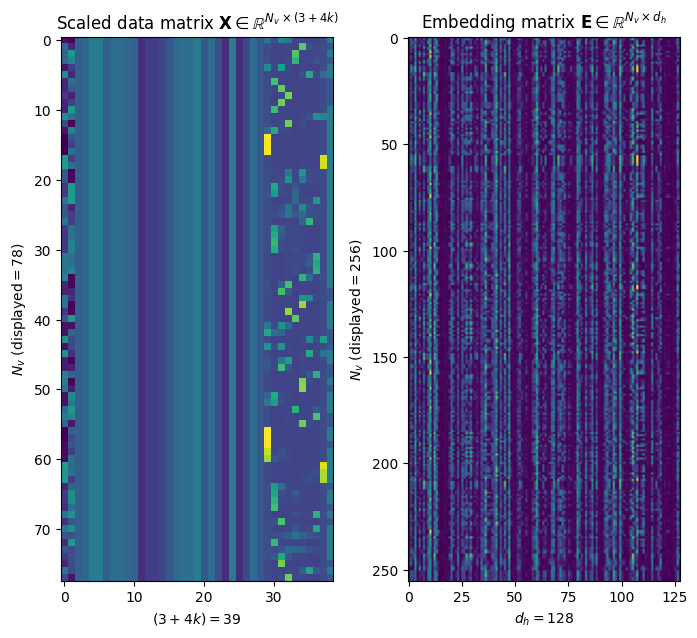

In [13]:
print(f"Input Shape             : {X_input.shape}")
print(f"Output Shape            : {E_matrix.shape}")
print(f"Contains NaN            : {torch.isnan(E_matrix).any().item()}")
print(f"Contains Inf            : {torch.isinf(E_matrix).any().item()}")
print(f"Mean Value              : {E_matrix.mean().item():.4f}")
print(f"Std Dev                 : {E_matrix.std().item():.4f}")
print(f"Spatial Var across Nodes: {E_matrix.std(dim=1).mean().item():.4f}")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7,7), dpi=100)
display_len_X, display_len_E = n_predictors*2, d_hidden*2
ax[0].set_title('Scaled data matrix $\\mathbf{X} \\in \\mathbb{R}^{N_v \\times (3+4k)}$')
ax[0].imshow(X_scaled.detach().cpu().numpy()[:display_len_X, :], aspect='equal')
ax[0].set_ylabel(rf'$N_v$ (displayed$={{{display_len_X}}}$)')
ax[0].set_xlabel(rf'$(3+4k) = {{{n_predictors}}}$')

ax[1].set_title('Embedding matrix $\\mathbf{E} \\in \\mathbb{R}^{N_v \\times d_{h}}$')
ax[1].imshow(E_matrix.squeeze().detach().cpu().numpy()[:display_len_E, :], aspect='equal')
ax[1].set_ylabel(rf'$N_v$ (displayed$={{{display_len_E}}}$)')
ax[1].set_xlabel(rf'$d_h = {{{d_hidden}}}$')

fig.tight_layout()
plt.savefig(f'Outputs/Raw&Embedded_data.png', bbox_inches='tight', pad_inches=0.01)
plt.show()

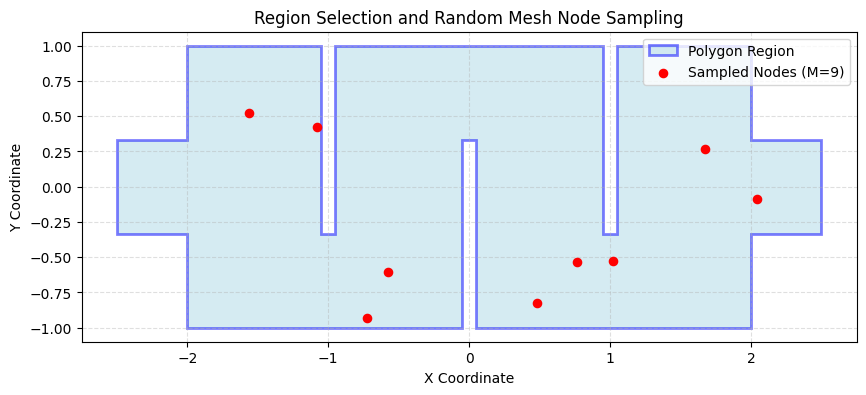

In [14]:
main_region = np.array([
    [ 0.95,  1.0],
    [ 0.95, -1/3],
    [ 1.05, -1/3],
    [ 1.05,  1.0],
    [ 2.00,  1.0],
    [ 2.00,  1/3],
    [ 2.50,  1/3],
    [ 2.50, -1/3],
    [ 2.00, -1/3],
    [ 2.00, -1.0],
    [ 0.05, -1.0],
    [ 0.05,  1/3],
    [-0.05,  1/3],
    [-0.05, -1.0],
    [-2.00, -1.0],
    [-2.00, -1/3],
    [-2.50, -1/3],
    [-2.50,  1/3],
    [-2.00,  1/3],
    [-2.00,  1.0],
    [-1.05,  1.0],
    [-1.05, -1/3],
    [-0.95, -1/3],
    [-0.95,  1.0],
    [ 0.95,  1.0]
])

from matplotlib.path import Path


poly_path = Path(main_region)
inside_mask = poly_path.contains_points(p_fine[:, :2])
polygon_indices = np.where(inside_mask)[0]

M = 9
rng = np.random.default_rng()
sample_size = min(M, len(polygon_indices))

# 1. Randomly pick M unique indices from the region
sampled_indices = rng.choice(polygon_indices, size=sample_size, replace=False)

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Extract the (x, y) coordinates for the sampled points
sampled_points = p_fine[sampled_indices]

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Plot the polygon in blue (with light blue fill and solid blue border)
poly_patch = Polygon(
    main_region,
    closed=True,
    facecolor="lightblue",
    edgecolor="blue",
    linewidth=2,
    alpha=0.5,
    label="Polygon Region",
)
ax.add_patch(poly_patch)

# 2. Scatter plot the sampled points in red
ax.scatter(
    sampled_points[:, 0],
    sampled_points[:, 1],
    color="red",
    s=35,
    zorder=3,
    label=f"Sampled Nodes (M={sample_size})",
)

# Formatting for equal spatial aspect ratio and clean display
ax.set_aspect("equal")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_title("Region Selection and Random Mesh Node Sampling")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="upper right")

# Set axis padding around the region
x_pad = (main_region[:, 0].max() - main_region[:, 0].min()) * 0.05
y_pad = (main_region[:, 1].max() - main_region[:, 1].min()) * 0.05
ax.set_xlim(main_region[:, 0].min() - x_pad, main_region[:, 0].max() + x_pad)
ax.set_ylim(main_region[:, 1].min() - y_pad, main_region[:, 1].max() + y_pad)

plt.show()